In [9]:
import duckdb

con = duckdb.connect()
con.execute("INSTALL httpfs; LOAD httpfs;")

LIMIT = 2_000_000

df = con.execute(f"""
    SELECT t.*, m.result, m.status, m.open_time, m.close_time
    FROM 'hf://datasets/TrevorJS/kalshi-trades/trades-*.parquet' t
    JOIN 'hf://datasets/TrevorJS/kalshi-trades/markets-*.parquet' m
      ON t.ticker = m.ticker
    WHERE m.result IN ('yes','no')
    LIMIT {LIMIT}
""").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [10]:
df.columns

Index(['trade_id', 'ticker', 'count', 'yes_price', 'no_price', 'taker_side',
       'created_time', 'result', 'status', 'open_time', 'close_time'],
      dtype='str')

In [11]:
# --- Kalshi Favorite-Longshot Bias: calibration table (reproduces Fig. 3) ---
import numpy as np
import pandas as pd
from scipy import stats

# Restrict to taker-YES trades only
tk = df[df['taker_side'] == 'yes'].copy()

# Implied probability from price (cents -> [0,1]); binary outcome Y_i
tk['p'] = tk['yes_price'] / 100.0
tk['y'] = (tk['result'] == 'yes').astype(int)

# 5-cent buckets on implied probability: [0,0.05), [0.05,0.10), ... , [0.95,1.00]
edges = np.arange(0.0, 1.0 + 1e-9, 0.05)
tk['bucket'] = pd.cut(tk['p'], bins=edges, include_lowest=True, right=False)

rows = []
for b, g in tk.groupby('bucket', observed=True):
    n = len(g)
    if n == 0:
        continue
    pbar = g['p'].mean()          # P_bar_b : mean implied prob in bucket
    f = g['y'].mean()             # f(b)    : empirical YES win rate
    delta = f - pbar              # delta_b = f(b) - P_bar_b
    # one-sample t-test that per-trade deviation (y - p) has mean 0
    dev = g['y'] - g['p']
    if n > 1 and dev.std(ddof=1) > 0:
        t, pval = stats.ttest_1samp(dev, 0.0)
    else:
        t, pval = np.nan, np.nan
    rows.append({'bucket': b, 'mid': b.mid, 'n': n,
                 'pbar': pbar, 'f': f, 'delta': delta, 't': t, 'pval': pval})

cal = pd.DataFrame(rows).sort_values('mid').reset_index(drop=True)
cal_disp = cal.assign(
    delta_pp=(cal['delta'] * 100).round(2),
    pbar=cal['pbar'].round(3), f=cal['f'].round(3),
    t=cal['t'].round(2), pval=cal['pval'].round(4),
)[['mid', 'n', 'pbar', 'f', 'delta_pp', 't', 'pval']]
print(f"taker-YES trades: {len(tk):,}  |  non-empty buckets: {len(cal)}")
cal_disp

taker-YES trades: 1,408,552  |  non-empty buckets: 20


,mid,n,pbar,f,delta_pp,t,pval
0,0.025,77264,0.020,0.009,-1.06,-31.06,0.0000
1,0.075,72365,0.070,0.040,-2.96,-40.40,0.0000
2,0.125,96962,0.126,0.097,-2.90,-30.53,0.0000
3,0.175,60990,0.175,0.180,0.46,2.96,0.0031
4,0.225,95843,0.220,0.228,0.78,5.80,0.0000
5,0.275,115007,0.275,0.215,-5.95,-49.17,0.0000
6,0.325,82040,0.328,0.299,-2.91,-18.21,0.0000
7,0.375,71657,0.376,0.323,-5.30,-30.38,0.0000
8,0.425,88742,0.419,0.391,-2.90,-17.71,0.0000
9,0.475,109603,0.471,0.437,-3.39,-22.69,0.0000


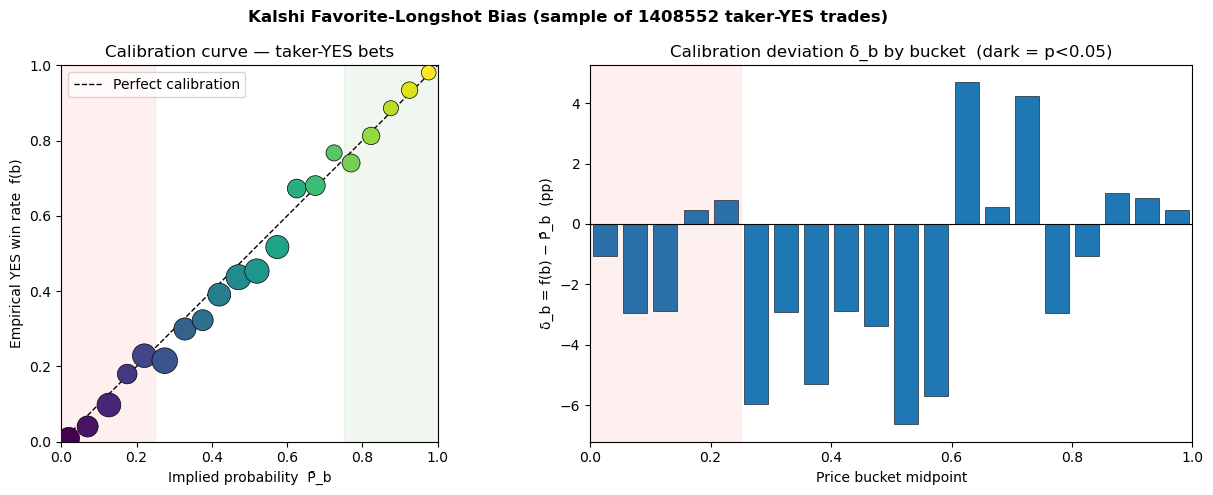

In [12]:
# --- Two-panel figure matching Fig. 3 ---
import matplotlib.pyplot as plt

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5))

# Left: calibration curve P_bar_b (x) vs f(b) (y), with 45-degree perfect line.
# Marker size ~ trade count so thin/noisy buckets are visually obvious.
sizes = 40 + 300 * (cal['n'] / cal['n'].max())
axL.plot([0, 1], [0, 1], 'k--', lw=1, label='Perfect calibration')
sc = axL.scatter(cal['pbar'], cal['f'], s=sizes, c=cal['mid'],
                 cmap='viridis', edgecolor='k', linewidth=0.5, zorder=3)
axL.axvspan(0, 0.25, color='red', alpha=0.06)      # longshot zone (<25c)
axL.axvspan(0.75, 1.0, color='green', alpha=0.06)  # favorite zone (>75c)
axL.set_xlim(0, 1); axL.set_ylim(0, 1)
axL.set_xlabel('Implied probability  P̄_b'); axL.set_ylabel('Empirical YES win rate  f(b)')
axL.set_title('Calibration curve — taker-YES bets')
axL.legend(loc='upper left'); axL.set_aspect('equal')

# Right: bar chart of delta_b (pp) by bucket; significant buckets (p<0.05) darker.
mids = cal['mid'].astype(float)
delta_pp = cal['delta'] * 100
sig = cal['pval'] < 0.05
colors = ['#1f77b4' if s else '#9ecae1' for s in sig]
axR.bar(mids, delta_pp, width=0.04, color=colors, edgecolor='k', linewidth=0.4)
axR.axhline(0, color='k', lw=0.8)
axR.axvspan(0, 0.25, color='red', alpha=0.06)
axR.set_xlim(0, 1)
axR.set_xlabel('Price bucket midpoint'); axR.set_ylabel('δ_b = f(b) − P̄_b  (pp)')
axR.set_title('Calibration deviation δ_b by bucket  (dark = p<0.05)')

fig.suptitle('Kalshi Favorite-Longshot Bias (sample of %d taker-YES trades)' % len(tk),
             fontweight='bold')
plt.tight_layout()
plt.show()

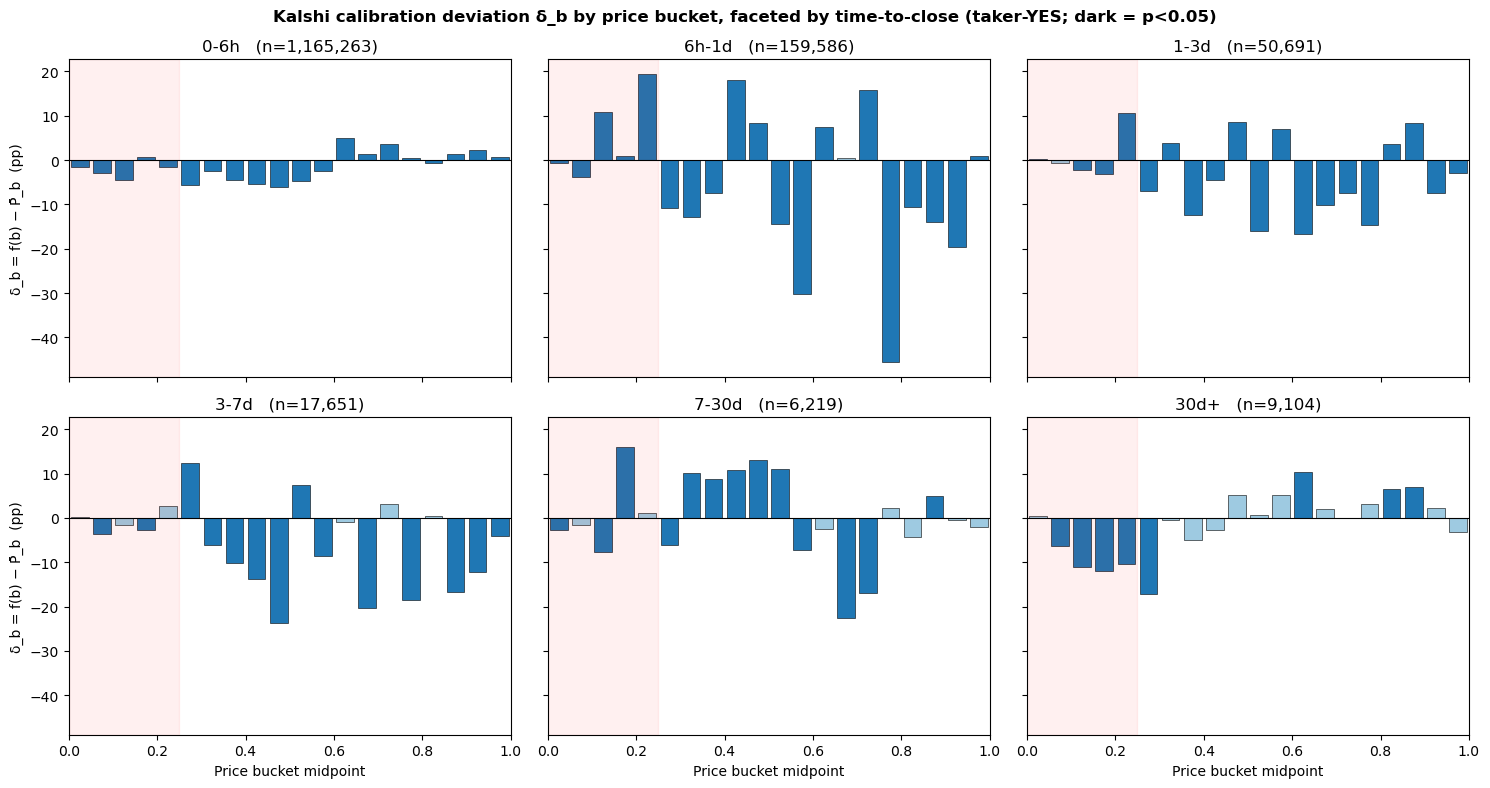

In [13]:
# --- delta_b by price bucket, faceted by time-to-close ---
# Same scope as the calibration cell above (taker-YES trades). For each
# time-to-close horizon we redraw the right-hand bar chart (delta_b across
# 5-cent price buckets) to see whether the longshot bias varies by horizon.
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

d = df[df['taker_side'] == 'yes'].copy()
d['p'] = d['yes_price'] / 100.0
d['y'] = (d['result'] == 'yes').astype(int)

# Parse timestamps robustly: numeric unix (s or ms) or ISO strings -> tz-aware datetime
def to_dt(s):
    if pd.api.types.is_datetime64_any_dtype(s):
        return pd.to_datetime(s, utc=True)
    if pd.api.types.is_numeric_dtype(s):
        v = pd.to_numeric(s, errors='coerce')
        unit = 'ms' if v.dropna().median() > 1e12 else 's'   # seconds vs milliseconds
        return pd.to_datetime(v, unit=unit, utc=True, errors='coerce')
    return pd.to_datetime(s, utc=True, errors='coerce')

# time_to_close in hours = close_time - created_time
d['ttc_h'] = (to_dt(d['close_time']) - to_dt(d['created_time'])).dt.total_seconds() / 3600.0
d = d[d['ttc_h'].notna() & (d['ttc_h'] >= 0)].copy()   # drop missing/negative durations

# Time-to-close bins (mirror the paper's time-to-resolution buckets)
ttc_edges  = [0, 6, 24, 72, 168, 720, np.inf]           # hours
ttc_labels = ['0-6h', '6h-1d', '1-3d', '3-7d', '7-30d', '30d+']
d['ttc_bucket'] = pd.cut(d['ttc_h'], bins=ttc_edges, labels=ttc_labels, right=False)

# 5-cent price buckets
price_edges = np.arange(0.0, 1.0 + 1e-9, 0.05)

def calib(sub):
    """Per price-bucket delta_b = f(b) - P_bar_b with a one-sample t-test on (y - p)."""
    sub = sub.copy()
    sub['pb'] = pd.cut(sub['p'], bins=price_edges, include_lowest=True, right=False)
    out = []
    for b, g in sub.groupby('pb', observed=True):
        if len(g) == 0:
            continue
        dev = g['y'] - g['p']
        t, pv = (stats.ttest_1samp(dev, 0.0)
                 if len(g) > 1 and dev.std(ddof=1) > 0 else (np.nan, np.nan))
        out.append({'mid': float(b.mid), 'n': len(g),
                    'delta': g['y'].mean() - g['p'].mean(), 'pval': pv})
    return pd.DataFrame(out).sort_values('mid')

# Small multiples: one delta_b bar chart per time-to-close bucket (shared axes)
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)
for ax, lab in zip(axes.ravel(), ttc_labels):
    sub = d[d['ttc_bucket'] == lab]
    c = calib(sub)
    if len(c) == 0:
        ax.set_title(f'{lab}  (no trades)')
        continue
    colors = ['#1f77b4' if s else '#9ecae1' for s in (c['pval'] < 0.05)]  # dark = p<0.05
    ax.bar(c['mid'], c['delta'] * 100, width=0.04, color=colors, edgecolor='k', linewidth=0.4)
    ax.axhline(0, color='k', lw=0.8)
    ax.axvspan(0, 0.25, color='red', alpha=0.06)   # longshot zone (<25c)
    ax.set_xlim(0, 1)
    ax.set_title(f'{lab}   (n={len(sub):,})')

for ax in axes[-1]:
    ax.set_xlabel('Price bucket midpoint')
for ax in axes[:, 0]:
    ax.set_ylabel('δ_b = f(b) − P̄_b  (pp)')
fig.suptitle('Kalshi calibration deviation δ_b by price bucket, faceted by time-to-close '
             '(taker-YES; dark = p<0.05)', fontweight='bold')
plt.tight_layout()
plt.show()

OLS per price bucket:  dev=(y - p)  ~  time_to_close (days)   [taker-YES]


,mid,n,slope_pp_day,intercept_pp,pval,r2
0,0.025,77232,0.021,-1.07,0.0263,0.000
1,0.075,72365,-0.012,-2.94,0.1149,0.000
2,0.125,96962,-0.086,-2.78,0.0000,0.001
3,0.175,60990,-0.091,0.57,0.0000,0.001
4,0.225,95843,-0.065,0.83,0.0000,0.000
5,0.275,115007,-0.066,-5.90,0.0000,0.000
6,0.325,82040,-0.042,-2.88,0.0278,0.000
7,0.375,71657,0.027,-5.32,0.2164,0.000
8,0.425,88742,0.021,-2.91,0.1669,0.000
9,0.475,109603,0.027,-3.41,0.1557,0.000


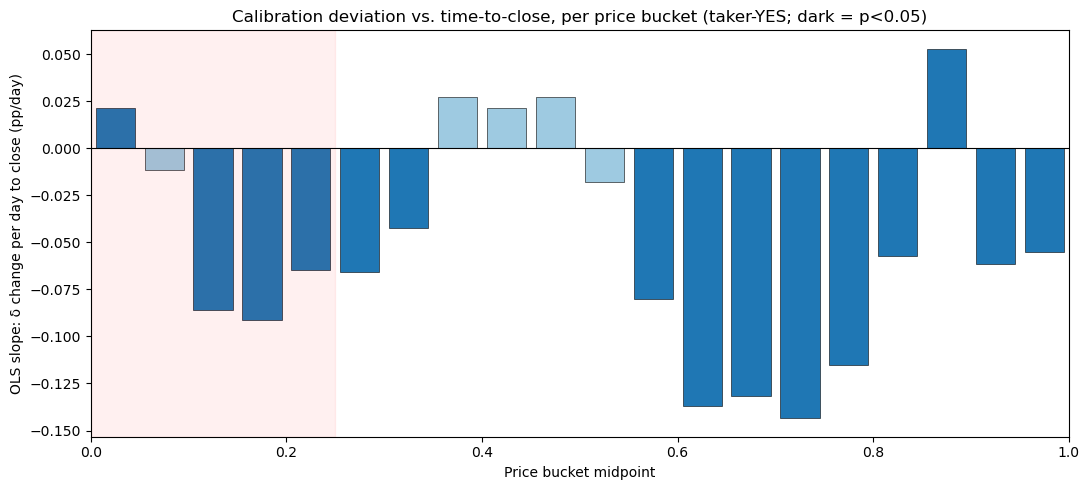

In [14]:
# --- Regress calibration deviation (delta) on time-to-close, per price bucket ---
# For each 5-cent price bucket, OLS of the per-trade deviation (y - p) on
# time_to_close (days). The bucket mean of (y - p) is delta_b, so the slope
# answers: does the calibration deviation drift as the horizon grows, and does
# that differ by price level? Scope = taker-YES (matches the cells above).
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

r = df[df['taker_side'] == 'yes'].copy()
r['p'] = r['yes_price'] / 100.0
r['y'] = (r['result'] == 'yes').astype(int)
r['dev'] = r['y'] - r['p']               # per-trade deviation; bucket mean = delta_b

# Parse timestamps robustly (numeric unix s/ms or ISO strings) -> tz-aware datetime
def to_dt(s):
    if pd.api.types.is_datetime64_any_dtype(s):
        return pd.to_datetime(s, utc=True)
    if pd.api.types.is_numeric_dtype(s):
        v = pd.to_numeric(s, errors='coerce')
        unit = 'ms' if v.dropna().median() > 1e12 else 's'
        return pd.to_datetime(v, unit=unit, utc=True, errors='coerce')
    return pd.to_datetime(s, utc=True, errors='coerce')

# time_to_close in days
r['ttc_d'] = (to_dt(r['close_time']) - to_dt(r['created_time'])).dt.total_seconds() / 86400.0
r = r[r['ttc_d'].notna() & (r['ttc_d'] >= 0)].copy()

# 5-cent price buckets
price_edges = np.arange(0.0, 1.0 + 1e-9, 0.05)
r['pb'] = pd.cut(r['p'], bins=price_edges, include_lowest=True, right=False)

# One OLS per price bucket: dev ~ time_to_close(days)
rows = []
for b, g in r.groupby('pb', observed=True):
    n = len(g)
    if n < 10 or g['ttc_d'].nunique() < 2:      # too few / no time variation to fit
        rows.append({'mid': float(b.mid), 'n': n, 'slope_pp_day': np.nan,
                     'intercept_pp': np.nan, 'pval': np.nan, 'r2': np.nan})
        continue
    lr = stats.linregress(g['ttc_d'], g['dev'])
    rows.append({'mid': float(b.mid), 'n': n,
                 'slope_pp_day': lr.slope * 100,      # change in delta per extra day to close (pp)
                 'intercept_pp': lr.intercept * 100,  # delta at time-to-close = 0 (pp)
                 'pval': lr.pvalue, 'r2': lr.rvalue ** 2})

reg = pd.DataFrame(rows).sort_values('mid').reset_index(drop=True)
print("OLS per price bucket:  dev=(y - p)  ~  time_to_close (days)   [taker-YES]")
display(reg.round({'mid': 3, 'slope_pp_day': 3, 'intercept_pp': 2, 'pval': 4, 'r2': 3}))

# Bar chart: time slope by price bucket (dark = p<0.05)
fig, ax = plt.subplots(figsize=(11, 5))
colors = ['#1f77b4' if pv < 0.05 else '#9ecae1' for pv in reg['pval'].fillna(1)]
ax.bar(reg['mid'], reg['slope_pp_day'], width=0.04, color=colors, edgecolor='k', linewidth=0.4)
ax.axhline(0, color='k', lw=0.8)
ax.axvspan(0, 0.25, color='red', alpha=0.06)   # longshot zone
ax.set_xlim(0, 1)
ax.set_xlabel('Price bucket midpoint')
ax.set_ylabel('OLS slope: δ change per day to close (pp/day)')
ax.set_title('Calibration deviation vs. time-to-close, per price bucket '
             '(taker-YES; dark = p<0.05)')
plt.tight_layout()
plt.show()

Taker-YES volume-weighted VWAR by price bucket (maker VWAR = negative of this)


,pmid,vwar_pp,contracts,n
0,0.025,-0.713,46917407.0,77232.0
1,0.075,-2.775,16572566.0,72365.0
2,0.125,-1.197,22358660.0,96962.0
3,0.175,1.740,11394221.0,60990.0
4,0.225,0.581,21518118.0,95843.0
5,0.275,-3.493,22556136.0,115007.0
6,0.325,-1.881,16099223.0,82040.0
7,0.375,-5.510,12756603.0,71657.0
8,0.425,-4.878,16230037.0,88742.0
9,0.475,-7.593,21210454.0,109603.0


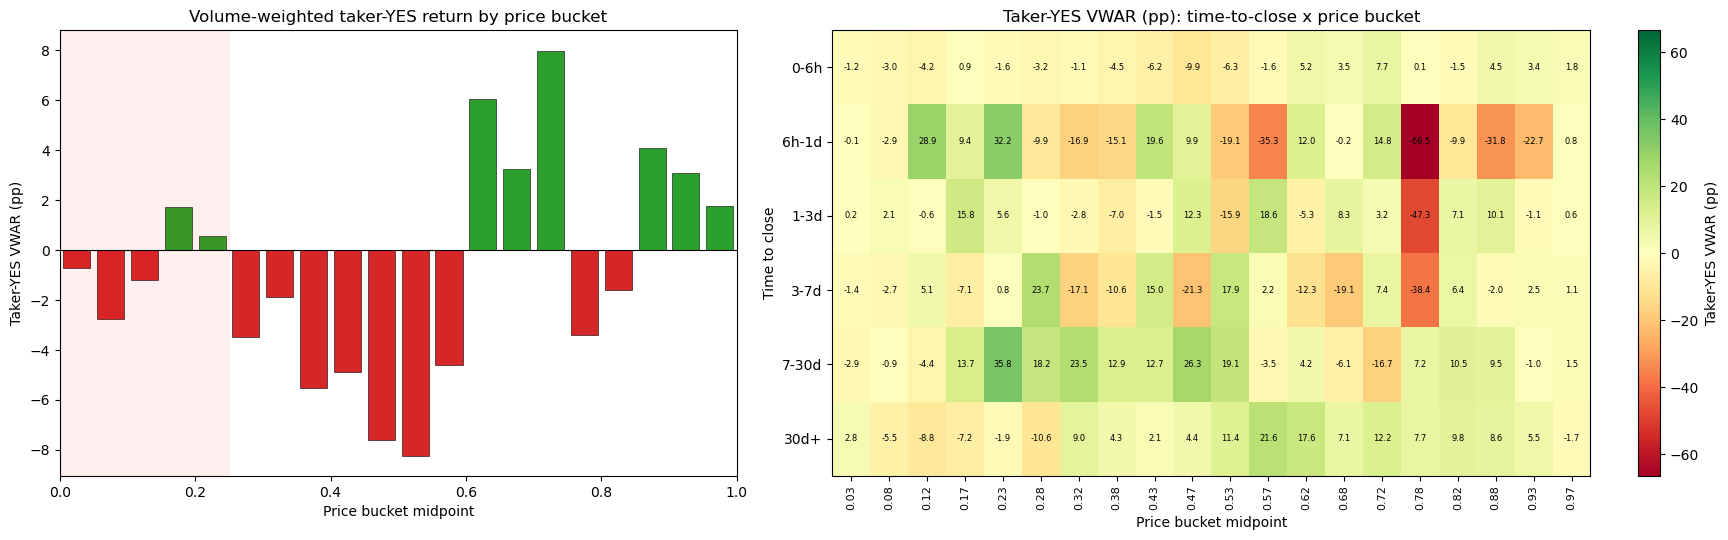

In [15]:
# --- Volume-weighted average returns (VWAR) by price bucket and time-to-close ---
# Taker-YES perspective: per-contract return Pi = y - p, volume-weighted by `count`
# (contracts per trade), i.e. VWAR = sum(Pi * count) / sum(count), in pp.
# Maker VWAR is just the negative of these (zero-sum). Scope = taker-YES.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

v = df[df['taker_side'] == 'yes'].copy()
v['p'] = v['yes_price'] / 100.0
v['y'] = (v['result'] == 'yes').astype(int)
v['pi'] = v['y'] - v['p']                                   # per-contract taker-YES return
v['w'] = pd.to_numeric(v['count'], errors='coerce').fillna(0).clip(lower=0)   # volume weight

# Parse timestamps robustly (numeric unix s/ms or ISO strings) -> tz-aware datetime
def to_dt(s):
    if pd.api.types.is_datetime64_any_dtype(s):
        return pd.to_datetime(s, utc=True)
    if pd.api.types.is_numeric_dtype(s):
        x = pd.to_numeric(s, errors='coerce')
        u = 'ms' if x.dropna().median() > 1e12 else 's'
        return pd.to_datetime(x, unit=u, utc=True, errors='coerce')
    return pd.to_datetime(s, utc=True, errors='coerce')

v['ttc_h'] = (to_dt(v['close_time']) - to_dt(v['created_time'])).dt.total_seconds() / 3600.0
v = v[v['ttc_h'].notna() & (v['ttc_h'] >= 0)].copy()

# 5-cent price buckets + time-to-close buckets (paper's horizon bins)
price_edges = np.arange(0.0, 1.0 + 1e-9, 0.05)
v['pb'] = pd.cut(v['p'], bins=price_edges, include_lowest=True, right=False)
v['pmid'] = v['pb'].map(lambda b: float(b.mid))
ttc_edges  = [0, 6, 24, 72, 168, 720, np.inf]
ttc_labels = ['0-6h', '6h-1d', '1-3d', '3-7d', '7-30d', '30d+']
v['ttc_bucket'] = pd.cut(v['ttc_h'], bins=ttc_edges, labels=ttc_labels, right=False)

def vwar(g):
    """Volume-weighted average taker-YES return (pp)."""
    w = g['w'].values
    return np.average(g['pi'].values, weights=w) * 100 if w.sum() > 0 else np.nan

# (1) VWAR by price bucket
pb_tbl = (v.groupby('pmid', observed=True)
            .apply(lambda g: pd.Series({'vwar_pp': vwar(g),
                                        'contracts': g['w'].sum(), 'n': len(g)}))
            .reset_index().sort_values('pmid'))
print("Taker-YES volume-weighted VWAR by price bucket (maker VWAR = negative of this)")
display(pb_tbl.round({'pmid': 3, 'vwar_pp': 3}))

# (2) VWAR on the time-to-close x price grid
grid = (v.groupby(['ttc_bucket', 'pmid'], observed=True)
          .apply(vwar).unstack('pmid').reindex(ttc_labels))

# --- Figure: bar chart (price-only) + heatmap (time x price) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 5.5),
                               gridspec_kw={'width_ratios': [1, 1.4]})

# Bar: VWAR by price bucket (green = taker gains, red = taker losses)
colors = ['#2ca02c' if x >= 0 else '#d62728' for x in pb_tbl['vwar_pp']]
ax1.bar(pb_tbl['pmid'], pb_tbl['vwar_pp'], width=0.04, color=colors, edgecolor='k', linewidth=0.4)
ax1.axhline(0, color='k', lw=0.8)
ax1.axvspan(0, 0.25, color='red', alpha=0.06)
ax1.set_xlim(0, 1)
ax1.set_xlabel('Price bucket midpoint')
ax1.set_ylabel('Taker-YES VWAR (pp)')
ax1.set_title('Volume-weighted taker-YES return by price bucket')

# Heatmap: VWAR across time-to-close (rows) x price bucket (cols), diverging at 0
vmax = np.nanmax(np.abs(grid.values)) if np.isfinite(grid.values).any() else 1.0
im = ax2.imshow(grid.values, aspect='auto', cmap='RdYlGn', vmin=-vmax, vmax=vmax)
ax2.set_xticks(range(len(grid.columns)))
ax2.set_xticklabels([f'{c:.2f}' for c in grid.columns], rotation=90, fontsize=8)
ax2.set_yticks(range(len(grid.index)))
ax2.set_yticklabels(grid.index)
ax2.set_xlabel('Price bucket midpoint')
ax2.set_ylabel('Time to close')
ax2.set_title('Taker-YES VWAR (pp): time-to-close x price bucket')
for i in range(grid.shape[0]):
    for j in range(grid.shape[1]):
        val = grid.values[i, j]
        if not np.isnan(val):
            ax2.text(j, i, f'{val:.1f}', ha='center', va='center', fontsize=6)
fig.colorbar(im, ax=ax2, label='Taker-YES VWAR (pp)')

plt.tight_layout()
plt.show()

In [16]:
# --- Diagnostic: what metadata does the markets parquet expose? ---
# If a 'category' / 'series_ticker' column already exists, the paper's category
# split is a join rather than a hand-rolled mapper.
schema = con.execute("""
    DESCRIBE SELECT * FROM 'hf://datasets/TrevorJS/kalshi-trades/markets-*.parquet'
""").df()
print("markets parquet columns:")
display(schema[['column_name', 'column_type']])

# Peek at a few rows of the most likely category-bearing fields (only those present)
candidates = [c for c in ['ticker', 'series_ticker', 'event_ticker',
                          'category', 'title', 'subtitle']
              if c in set(schema['column_name'])]
print("\ncandidate metadata fields found:", candidates)
if candidates:
    display(con.execute(
        f"SELECT {', '.join(candidates)} "
        f"FROM 'hf://datasets/TrevorJS/kalshi-trades/markets-*.parquet' LIMIT 10"
    ).df())

markets parquet columns:


,column_name,column_type
0,ticker,VARCHAR
1,event_ticker,VARCHAR
2,market_type,VARCHAR
3,title,VARCHAR
4,yes_sub_title,VARCHAR
5,no_sub_title,VARCHAR
6,status,VARCHAR
7,yes_bid,BIGINT
8,yes_ask,BIGINT
9,no_bid,BIGINT



candidate metadata fields found: ['ticker', 'event_ticker', 'title']


,ticker,event_ticker,title
0,CPI-21JUN-T0.6,CPI-21JUN,Will the Consumer Price Index (CPI) increase m...
1,TRDDEFCN-21MAY-T30,TRDDEFCN-21MAY,Will the US trade deficit in goods with China ...
2,GDP-21JUN30-T6.0,GDP-21JUN30,Will real GDP increase by more than 6%?
3,HOME-21JUN-T750,HOME-21JUN,"Will new U.S. home sales be above 750,000?"
4,TEMP-21-T2.124,TEMP-21,Will 2021 be the **hottest year on record**?
5,FED-21JUL-T0.25,FED-21JUL,Will the target federal funds rate be above 0....
6,TRDDEFCN-21JUN-T27,TRDDEFCN-21JUN,Will the US trade deficit in goods with China ...
7,CO2-21APR-T365,CO2-21APR-T36,Will the estimated US carbon dioxide emissions...
8,TRDDEFCN-21JUN-T28,TRDDEFCN-21JUN2,Will the US trade deficit in goods with China ...
9,SLOAN-21SEP30,SLOAN,Will federal student loan forbearance be exten...


In [17]:
# --- Series-prefix scan: what do we actually need to categorize? ---
# No 'category' column exists, but the ticker prefix (before the first '-') is a
# clean series code (CPI, FED, GDP, TEMP, ...). Rank prefixes by volume in THIS
# sample so we map where the volume is, and attach an example title per prefix
# (from the full markets metadata) to make category labeling easy.
import pandas as pd

df_s = df.assign(series=df['ticker'].str.split('-').str[0])
rank = (df_s.groupby('series')
             .agg(trades=('ticker', 'size'), contracts=('count', 'sum'))
             .sort_values('contracts', ascending=False))
rank['vol_share'] = (rank['contracts'] / rank['contracts'].sum()).round(4)
rank['cum_share'] = rank['vol_share'].cumsum().round(4)

# One representative title per series prefix, pulled from the full markets parquet
titles = con.execute("""
    SELECT split_part(ticker, '-', 1) AS series, any_value(title) AS example_title
    FROM 'hf://datasets/TrevorJS/kalshi-trades/markets-*.parquet'
    GROUP BY 1
""").df().set_index('series')['example_title']
rank['example_title'] = rank.index.map(titles)

print(f"distinct series prefixes in sample: {len(rank)}")
print(f"top 30 prefixes cover {rank['vol_share'].head(30).sum():.1%} of sample volume")
display(rank.head(40))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

distinct series prefixes in sample: 341
top 30 prefixes cover 96.5% of sample volume


,trades,contracts,vol_share,cum_share,example_title
series,,,,,
KXNBAGAME,335921,93376845,0.2060,0.2060,Minnesota vs Oklahoma City Winner?
KXNCAAFGAME,304817,92340965,0.2038,0.4098,Florida Atlantic at Navy Winner?
KXNFLGAME,252119,82498641,0.1820,0.5918,Dallas vs Philadelphia Winner?
KXMVESPORTSMULTIGAMEEXTENDED,65655,36900266,0.0814,0.6732,"yes Jahmyr Gibbs,yes Mark Andrews,yes Jacksonv..."
KXBTCD,214354,17057926,0.0376,0.7108,"Bitcoin price on Feb 9, 2025?"
KXNFLSPREAD,55409,15373910,0.0339,0.7447,Indianapolis wins by over 10.5 points?
KXNCAAFSPREAD,76830,14468106,0.0319,0.7766,Missouri St. wins by over 1.5 points?
KXMVENFLSINGLEGAME,32603,12452899,0.0275,0.8041,"yes Philadelphia wins by over 7.5 points,no Ov..."
KXNCAAFTOTAL,61892,10813637,0.0239,0.8280,Missouri St. at Middle Tennessee: Total Points...


In [18]:
# --- Map ticker -> broad category (paper-style) ---
# Series code = text before the first '-'. We classify it with:
#   (a) anchored token match (optional 'KX' prefix) for league/topic codes that
#       sit at the START of the series, and
#   (b) a sports-descriptor fallback (re.search for GAME/COACH/...) to catch
#       sports series where the league is NOT at the start (e.g. MVE-NBA-..., MICH-COACH).
# Ordered: Sports is decided first, then the remaining categories; first match wins.
import re
import pandas as pd

P = r'^(?:KX)?'   # optional Kalshi 'KX' prefix

# Leagues that appear at the start of a sports series code
SPORTS_LEAGUES = (r'(NFL|NBA|WNBA|NHL|MLB|NCAA|CFB|CBB|CBA|NBL|UFC|BOXING|MMA|SOCCER|'
                  r'EPL|UCL|UEL|MLS|FIFA|EUROLEAGUE|SAUDIPL|AFCON|SERIEA|LALIGA|'
                  r'BUNDESLIGA|LIGUE1|COPA|CONCACAF|IPL|T20|CRICKET|RUGBY|TENNIS|ATP|'
                  r'WTA|GOLF|PGA|LPGA|F1|MOTOGP|NASCAR|OLYMPIC|MVE)')
# Sport descriptors that can appear anywhere in the code (league not at start)
SPORTS_DESC = r'(SINGLEGAME|MULTIGAME|GAME|COACH|SPREAD|MATCHUP|PLAYOFF)'

# Remaining categories, checked in order (anchored token match)
OTHER_RULES = [
    ('Crypto',        r'(BTC|ETH|SOL|XRP|DOGE|CRYPTO)'),       # ADA dropped (collides w/ ADAMS)
    ('Politics',      r'(PRES|SENATE|HOUSE|GOV|ELECT|POLL|CONGRESS|SCOTUS|IMPEACH|'
                      r'SHUTDOWN|DEBTCEIL|SLOAN|GASTAX|TRUMP|BIDEN|HARRIS|ADAMS|MAYOR|'
                      r'APPROVE|538)'),
    ('World Events',  r'(TRDDEF|TRADE|WAR|UKRAINE|RUSSIA|CHINA|OPEC|CO2|EMISS|NUKE)'),
    ('Weather',       r'(TEMP|HIGH|LOW|RAIN|SNOW|HURR|STORM|WEATHER)'),
    ('Entertainment', r'(OSCAR|EMMY|GRAMMY|MOVIE|BOXOFFICE|ROTTEN|SPOTIFY|BILLBOARD|'
                      r'TVRATING|NETFLIX|1SONG|SONG|ALBUM)'),
    ('Science/Tech',  r'(SPACE|NASA|ROCKET|GPT|IPHONE|TESLA|TECH)'),
    ('Finance',       r'(CPI|PCE|GDP|FED|FOMC|RATE|JOBS|PAYROLL|UNEMP|GBP|EUR|JPY|USD|'
                      r'FX|NASDAQ|SPX|SP500|DJIA|INX|INDU|GAS|OIL|WTI|BRENT|GOLD|HOME|'
                      r'MORTG|RECESS|10Y|2Y|30Y|YIELD|TREAS)'),
]

def categorize(ticker: str) -> str:
    """Map a Kalshi ticker (or series prefix) to a broad paper-style category."""
    s = (ticker or '').split('-')[0].upper().strip()   # series code
    if not s:
        return 'Other'
    if re.match(P + SPORTS_LEAGUES, s) or re.search(SPORTS_DESC, s):
        return 'Sports'
    for cat, toks in OTHER_RULES:
        if re.match(P + toks, s):
            return cat
    return 'Other'

# Apply to the sample
df_cat = df.assign(series=df['ticker'].str.split('-').str[0])
df_cat['category'] = df_cat['ticker'].map(categorize)

# Coverage + category breakdown by volume
cov = df_cat.loc[df_cat['category'] != 'Other', 'count'].sum() / df_cat['count'].sum()
summary = (df_cat.groupby('category')
                 .agg(trades=('ticker', 'size'), contracts=('count', 'sum'))
                 .assign(vol_share=lambda d: (d['contracts'] / d['contracts'].sum()).round(4))
                 .sort_values('contracts', ascending=False))
summary['prefixes'] = df_cat.groupby('category')['series'].agg(lambda s: sorted(set(s)))
print(f"volume coverage (non-Other): {cov:.1%}")
display(summary)

# --- Diagnostic 1: blank series — what are these raw tickers? ---
blank = df_cat[df_cat['series'].fillna('').str.strip() == '']
print(f"\nblank-series rows: {len(blank):,}")
if len(blank):
    print("example raw ticker values (repr):", [repr(t) for t in blank['ticker'].unique()[:10]])

# --- Diagnostic 2: top prefixes still landing in 'Other' (by volume), to keep iterating ---
oth = (df_cat[df_cat['category'] == 'Other']
       .groupby('series')['count'].sum().sort_values(ascending=False))
print(f"\ntop unmapped prefixes ('Other') by volume:")
display(oth.head(20).to_frame('contracts'))

volume coverage (non-Other): 99.6%


,trades,contracts,vol_share,prefixes
category,,,,
Sports,1654163,425486804,0.9389,"[KXAFCONGAME, KXALEAGUEGAME, KXBELGIANPLGAME, ..."
Crypto,238460,19002005,0.0419,"[KXBTC, KXBTC15M, KXBTC2025100, KXBTCD, KXBTCV..."
Politics,31226,2149065,0.0047,"[538APPROVE, ADAMS, GASTAX, KXPRESNOMFEDCHAIR,..."
Weather,29919,1827790,0.0040,"[KXHIGHAUS, KXHIGHCHI, KXHIGHDEN, KXHIGHLAX, K..."
Finance,20761,1819649,0.0040,"[10Y2Y, 10Y3M, GAS, GASD, GASM, GASMAX, GASMIN..."
Other,14501,1795872,0.0040,"[, AILEGISLATION, ALTMAN, AMBCN, AMCCEOCHANGE,..."
Entertainment,10569,1103173,0.0024,"[1SONG, 1SONGBILLIEEILISH, 1SONGCHAPPELLROAN, ..."
Science/Tech,401,11774,0.0000,"[KXSPACEXCOUNT, KXTECHLAYOFF, KXTESLA]"



blank-series rows: 66
example raw ticker values (repr): ["'-23MAR-T2'", "'-23MAR-T3'"]

top unmapped prefixes ('Other') by volume:


,contracts
series,
KXRANKLISTTIMEMAG,466200
KXMULTIPREPACK,334292
KXBATTLEOFSEXES,192978
KXAAAGASW,79127
KXMADUROOUT,72446
AMBCN,60766
KXEPSTEIN,59673
AILEGISLATION,53225
KXRTANACONDA,43267


In [19]:
# ============================================================================
# Reusable Kalshi analysis library (DuckDB-backed; scales to the full dataset).
# Every function computes *sufficient statistics* in SQL and returns a small
# DataFrame, so the same code runs on the sample or all 72M trades.
# Depends on `categorize` (defined in the category-mapping cell above) and `con`.
# ============================================================================
import os
import numpy as np
import pandas as pd
from scipy import stats

TRADES_GLOB  = 'hf://datasets/TrevorJS/kalshi-trades/trades-*.parquet'
MARKETS_GLOB = 'hf://datasets/TrevorJS/kalshi-trades/markets-*.parquet'

PRICE_BIN = 5   # cent width of price buckets
# Time-to-close bucket expression (operates on a column named ttc_h) + display order
TTC_CASE = ("CASE WHEN ttc_h < 6 THEN '0-6h' WHEN ttc_h < 24 THEN '6h-1d' "
            "WHEN ttc_h < 72 THEN '1-3d' WHEN ttc_h < 168 THEN '3-7d' "
            "WHEN ttc_h < 720 THEN '7-30d' ELSE '30d+' END")
TTC_ORDER = ['0-6h', '6h-1d', '1-3d', '3-7d', '7-30d', '30d+']


def _epoch_expr(typestr: str, col: str) -> str:
    """SQL expression converting a timestamp/unix-int/ISO-string column to epoch seconds."""
    t = typestr.upper()
    if 'TIMESTAMP' in t or 'DATE' in t:
        return f"epoch({col})"
    if any(k in t for k in ('INT', 'DEC', 'DOUBLE', 'FLOAT', 'REAL')):
        return f"(CASE WHEN {col} > 1e12 THEN {col}/1000.0 ELSE CAST({col} AS DOUBLE) END)"
    return f"epoch(TRY_CAST({col} AS TIMESTAMP))"


def _try(con, sql):
    """Run a SET/PRAGMA, ignoring it if this DuckDB build doesn't know the option."""
    try:
        con.execute(sql)
    except Exception as e:
        print(f"  (skipped: {sql} -> {str(e)[:60]})")


def build_cache(con, dst='kalshi_trades.parquet', limit=None, overwrite=False,
                threads=2, hf_token=None):
    """Process trades x markets once into a slim local parquet (the full-dataset scan).

    Keeps only needed columns, normalizes timestamps to epoch seconds, pre-filters
    to finalized markets, and writes locally so later analysis avoids re-streaming.

    Reading from hf:// fires many parallel HTTP range requests; HuggingFace will
    return HTTP 429 (Too Many Requests) if hit too hard. To stay under the limit we
    lower `threads` and enable retry-with-backoff. Pass `hf_token='hf_...'` for a
    higher rate limit. If 429s persist, download the parquet files locally first
    (see note in the cell below) and point TRADES_GLOB/MARKETS_GLOB at them.

    limit=N builds a quick test slice; limit=None builds all ~72M trades.
    """
    if os.path.exists(dst) and not overwrite:
        n = con.execute(f"SELECT count(*) FROM '{dst}'").fetchone()[0]
        print(f"cache exists: {dst} ({n:,} rows). Use overwrite=True to rebuild.")
        return dst

    con.execute("PRAGMA enable_progress_bar;")
    con.execute(f"SET threads TO {threads};")          # fewer concurrent HTTP range requests
    for s in ("SET http_retries=10",                   # ride out HTTP 429 with backoff
              "SET http_retry_wait_ms=2000",
              "SET http_retry_backoff=2",
              "SET enable_http_metadata_cache=true",
              "SET http_keep_alive=true"):
        _try(con, s)
    hf_token = hf_token or os.environ.get('HF_TOKEN')   # never hardcode the token in the cell
    if hf_token:
        _try(con, f"CREATE OR REPLACE SECRET hf (TYPE HUGGINGFACE, TOKEN '{hf_token}')")

    ct  = con.execute(f"SELECT typeof(created_time) FROM '{TRADES_GLOB}' LIMIT 1").fetchone()[0]
    clt = con.execute(f"SELECT typeof(close_time) FROM '{MARKETS_GLOB}' LIMIT 1").fetchone()[0]
    created_s, close_s = _epoch_expr(ct, 't.created_time'), _epoch_expr(clt, 'm.close_time')
    lim = f"LIMIT {int(limit)}" if limit else ""

    tmp = dst + '.tmp'                                  # write atomically: no half-built cache
    con.execute(f"""
        COPY (
            SELECT t.ticker, t.count, t.yes_price, t.taker_side,
                   m.result, split_part(t.ticker, '-', 1) AS series,
                   {created_s} AS created_s, {close_s} AS close_s
            FROM '{TRADES_GLOB}' t
            JOIN (SELECT ticker, result, close_time FROM '{MARKETS_GLOB}'
                  WHERE result IN ('yes','no')) m USING (ticker)
            WHERE t.taker_side IN ('yes','no')
            {lim}
        ) TO '{tmp}' (FORMAT parquet);
    """)
    os.replace(tmp, dst)
    n = con.execute(f"SELECT count(*) FROM '{dst}'").fetchone()[0]
    print(f"cached {n:,} rows -> {dst}")
    return dst


def _add_ttest(df, mean='delta', sd='sd_dev', n='n'):
    """Add t-stat and two-sided p-value from per-group (mean, std, n)."""
    df = df.copy()
    df['t'] = df[mean] / (df[sd] / np.sqrt(df[n]))
    df['pval'] = 2 * stats.t.sf(np.abs(df['t']), (df[n] - 1).clip(lower=1))
    return df


def calibration_table(con, source, side='yes'):
    """Per 5c price bucket: pbar, f(b), delta_b = f - pbar, with one-sample t-test."""
    q = f"""
        SELECT (yes_price // {PRICE_BIN}) * {PRICE_BIN} / 100.0 AS bin_lo,
               count(*) AS n, sum(count) AS contracts,
               avg(yes_price/100.0) AS pbar, avg((result='yes')::INT) AS f,
               avg((result='yes')::INT - yes_price/100.0) AS delta,
               stddev_samp((result='yes')::INT - yes_price/100.0) AS sd_dev
        FROM {source} WHERE taker_side = '{side}'
        GROUP BY 1 ORDER BY 1
    """
    cal = _add_ttest(con.execute(q).df())
    cal['mid'] = cal['bin_lo'] + PRICE_BIN / 200.0
    return cal


def calibration_by_ttc(con, source, side='yes'):
    """delta_b per (time-to-close bucket x price bucket), with t-test."""
    q = f"""
        WITH base AS (
            SELECT (yes_price // {PRICE_BIN}) * {PRICE_BIN} / 100.0 AS bin_lo,
                   (close_s - created_s)/3600.0 AS ttc_h,
                   (result='yes')::INT - yes_price/100.0 AS dev
            FROM {source} WHERE taker_side = '{side}' AND close_s >= created_s
        )
        SELECT {TTC_CASE} AS ttc_bucket, bin_lo, count(*) AS n,
               avg(dev) AS delta, stddev_samp(dev) AS sd_dev
        FROM base GROUP BY 1, 2 ORDER BY 2
    """
    d = _add_ttest(con.execute(q).df())
    d['mid'] = d['bin_lo'] + PRICE_BIN / 200.0
    return d


def deltatime_regression(con, source, side='yes'):
    """Per price bucket: OLS of deviation (y-p) on time-to-close (days), via SQL regr_*."""
    q = f"""
        WITH base AS (
            SELECT (yes_price // {PRICE_BIN}) * {PRICE_BIN} / 100.0 AS bin_lo,
                   (close_s - created_s)/86400.0 AS ttc_d,
                   (result='yes')::INT - yes_price/100.0 AS dev
            FROM {source} WHERE taker_side = '{side}' AND close_s >= created_s
        )
        SELECT bin_lo, regr_count(dev, ttc_d) AS n,
               regr_slope(dev, ttc_d) AS slope, regr_intercept(dev, ttc_d) AS intercept,
               regr_r2(dev, ttc_d) AS r2, regr_sxx(dev, ttc_d) AS sxx,
               regr_syy(dev, ttc_d) AS syy, regr_sxy(dev, ttc_d) AS sxy
        FROM base GROUP BY 1 ORDER BY 1
    """
    r = con.execute(q).df()
    r['mid'] = r['bin_lo'] + PRICE_BIN / 200.0
    denom = (r['n'] - 2).clip(lower=1) * r['sxx']                 # slope standard error
    r['se'] = np.sqrt(((r['syy'] - r['slope'] * r['sxy']) / denom).clip(lower=0))
    r['t'] = r['slope'] / r['se']
    r['pval'] = 2 * stats.t.sf(np.abs(r['t']), (r['n'] - 2).clip(lower=1))
    r['slope_pp_day'] = r['slope'] * 100
    return r


def _taker_pnl(a=''):
    """Per-contract TAKER PnL over ALL trades (maker = -taker). `a` is an optional
    table alias. taker buys YES at p -> (y - p); taker buys NO at (1-p) -> (p - y)."""
    p = (a + '.') if a else ''
    return (f"(CASE WHEN {p}taker_side='yes' THEN ({p}result='yes')::INT - {p}yes_price/100.0 "
            f"ELSE {p}yes_price/100.0 - ({p}result='yes')::INT END)")


def vwar_by_price(con, source):
    """Volume-weighted taker/maker return (pp) per price bucket, over ALL trades."""
    q = f"""
        SELECT (yes_price // {PRICE_BIN}) * {PRICE_BIN} / 100.0 AS bin_lo,
               sum({_taker_pnl()} * count) / sum(count) * 100 AS vwar_pp,
               sum(count) AS contracts, count(*) AS n
        FROM {source}
        GROUP BY 1 ORDER BY 1
    """
    t = con.execute(q).df()
    t['maker_vwar_pp'] = -t['vwar_pp']
    t['mid'] = t['bin_lo'] + PRICE_BIN / 200.0
    return t


def vwar_grid(con, source):
    """Volume-weighted taker return (pp) on the time-to-close x price grid, over ALL trades."""
    q = f"""
        WITH base AS (
            SELECT (yes_price // {PRICE_BIN}) * {PRICE_BIN} / 100.0 AS bin_lo,
                   (close_s - created_s)/3600.0 AS ttc_h,
                   {_taker_pnl()} * count AS pnl, count AS w
            FROM {source} WHERE close_s >= created_s
        )
        SELECT {TTC_CASE} AS ttc_bucket, bin_lo, sum(pnl)/sum(w) * 100 AS vwar_pp
        FROM base GROUP BY 1, 2
    """
    g = con.execute(q).df()
    return g.pivot(index='ttc_bucket', columns='bin_lo', values='vwar_pp').reindex(TTC_ORDER)


def vwar_by_category(con, source, categorize_fn=None):
    """Volume-weighted taker/maker return (pp) per broad category, over ALL trades.
    Applies categorize to the DISTINCT prefixes only, then joins (fast at scale)."""
    fn = categorize_fn or categorize
    sm = con.execute(f"SELECT DISTINCT series FROM {source}").df()
    sm['category'] = sm['series'].map(fn)
    con.register('series_map', sm)
    q = f"""
        SELECT s.category,
               sum({_taker_pnl('t')} * t.count) / sum(t.count) * 100 AS taker_vwar_pp,
               sum(t.count) AS contracts, count(*) AS n
        FROM {source} t JOIN series_map s USING (series)
        GROUP BY 1 ORDER BY contracts DESC
    """
    o = con.execute(q).df()
    o['maker_vwar_pp'] = -o['taker_vwar_pp']
    return o

print("analysis library loaded.")


analysis library loaded.


In [20]:
# ============================================================================
# Plotting functions — consume the small aggregate DataFrames from the library.
# `sig_col`/`thresh`: at full scale every bucket is significant, so bars can be
# colored by EITHER p-value (sig_col='pval') or |effect| >= thresh (sig_col=None).
# ============================================================================
import numpy as np
import matplotlib.pyplot as plt

LONGSHOT, FAVORITE = 0.25, 0.75

def _emph(df, values_pp, sig_col='pval', thresh=0.0):
    """Boolean 'emphasize' mask: significant (p<0.05) or |effect| >= thresh."""
    if sig_col and sig_col in df:
        return (df[sig_col] < 0.05).values
    return (np.abs(values_pp) >= thresh).values


def plot_calibration(cal, title='Kalshi Favorite-Longshot Bias', sig_col='pval', thresh=0.0):
    fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5))
    sizes = 40 + 300 * (cal['n'] / cal['n'].max())
    axL.plot([0, 1], [0, 1], 'k--', lw=1, label='Perfect calibration')
    axL.scatter(cal['pbar'], cal['f'], s=sizes, c=cal['mid'], cmap='viridis',
                edgecolor='k', linewidth=0.5, zorder=3)
    axL.axvspan(0, LONGSHOT, color='red', alpha=0.06)
    axL.axvspan(FAVORITE, 1.0, color='green', alpha=0.06)
    axL.set_xlim(0, 1); axL.set_ylim(0, 1); axL.set_aspect('equal')
    axL.set_xlabel('Implied probability  P̄_b'); axL.set_ylabel('Empirical YES win rate  f(b)')
    axL.set_title('Calibration curve — taker-YES bets'); axL.legend(loc='upper left')

    delta_pp = cal['delta'] * 100
    emph = _emph(cal, delta_pp, sig_col, thresh)
    colors = ['#1f77b4' if e else '#9ecae1' for e in emph]
    axR.bar(cal['mid'], delta_pp, width=0.04, color=colors, edgecolor='k', linewidth=0.4)
    axR.axhline(0, color='k', lw=0.8); axR.axvspan(0, LONGSHOT, color='red', alpha=0.06)
    axR.set_xlim(0, 1)
    axR.set_xlabel('Price bucket midpoint'); axR.set_ylabel('δ_b = f(b) − P̄_b  (pp)')
    axR.set_title('Calibration deviation δ_b by bucket')
    fig.suptitle(title, fontweight='bold'); plt.tight_layout(); plt.show()


def plot_delta_facets(d, title='δ_b by price bucket, faceted by time-to-close',
                      sig_col='pval', thresh=0.0):
    fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)
    for ax, lab in zip(axes.ravel(), TTC_ORDER):
        sub = d[d['ttc_bucket'] == lab]
        if len(sub) == 0:
            ax.set_title(f'{lab}  (no trades)'); continue
        delta_pp = sub['delta'] * 100
        emph = _emph(sub, delta_pp, sig_col, thresh)
        colors = ['#1f77b4' if e else '#9ecae1' for e in emph]
        ax.bar(sub['mid'], delta_pp, width=0.04, color=colors, edgecolor='k', linewidth=0.4)
        ax.axhline(0, color='k', lw=0.8); ax.axvspan(0, LONGSHOT, color='red', alpha=0.06)
        ax.set_xlim(0, 1); ax.set_title(f"{lab}   (n={int(sub['n'].sum()):,})")
    for ax in axes[-1]:
        ax.set_xlabel('Price bucket midpoint')
    for ax in axes[:, 0]:
        ax.set_ylabel('δ_b (pp)')
    fig.suptitle(title, fontweight='bold'); plt.tight_layout(); plt.show()


def plot_deltatime(reg, title='Calibration deviation vs. time-to-close, per price bucket',
                   sig_col='pval', thresh=0.0):
    fig, ax = plt.subplots(figsize=(11, 5))
    emph = _emph(reg, reg['slope_pp_day'], sig_col, thresh)
    colors = ['#1f77b4' if e else '#9ecae1' for e in emph]
    ax.bar(reg['mid'], reg['slope_pp_day'], width=0.04, color=colors, edgecolor='k', linewidth=0.4)
    ax.axhline(0, color='k', lw=0.8); ax.axvspan(0, LONGSHOT, color='red', alpha=0.06)
    ax.set_xlim(0, 1)
    ax.set_xlabel('Price bucket midpoint'); ax.set_ylabel('δ change per day to close (pp/day)')
    ax.set_title(title, fontweight='bold'); plt.tight_layout(); plt.show()


def plot_vwar(pb, grid, title='Taker-YES volume-weighted returns'):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 5.5),
                                   gridspec_kw={'width_ratios': [1, 1.4]})
    colors = ['#2ca02c' if x >= 0 else '#d62728' for x in pb['vwar_pp']]
    ax1.bar(pb['mid'], pb['vwar_pp'], width=0.04, color=colors, edgecolor='k', linewidth=0.4)
    ax1.axhline(0, color='k', lw=0.8); ax1.axvspan(0, LONGSHOT, color='red', alpha=0.06)
    ax1.set_xlim(0, 1)
    ax1.set_xlabel('Price bucket midpoint'); ax1.set_ylabel('Taker-YES VWAR (pp)')
    ax1.set_title('VWAR by price bucket')

    vmax = np.nanmax(np.abs(grid.values)) if np.isfinite(grid.values).any() else 1.0
    im = ax2.imshow(grid.values, aspect='auto', cmap='RdYlGn', vmin=-vmax, vmax=vmax)
    ax2.set_xticks(range(len(grid.columns)))
    ax2.set_xticklabels([f'{c:.2f}' for c in grid.columns], rotation=90, fontsize=8)
    ax2.set_yticks(range(len(grid.index))); ax2.set_yticklabels(grid.index)
    ax2.set_xlabel('Price bucket midpoint'); ax2.set_ylabel('Time to close')
    ax2.set_title('VWAR (pp): time-to-close x price bucket')
    for i in range(grid.shape[0]):
        for j in range(grid.shape[1]):
            val = grid.values[i, j]
            if not np.isnan(val):
                ax2.text(j, i, f'{val:.1f}', ha='center', va='center', fontsize=6)
    fig.colorbar(im, ax=ax2, label='Taker-YES VWAR (pp)')
    fig.suptitle(title, fontweight='bold'); plt.tight_layout(); plt.show()


def plot_category(cat, title='Maker vs. Taker VWAR by category'):
    c = cat.sort_values('contracts')                      # smallest at top -> biggest at bottom
    y = np.arange(len(c)); h = 0.4
    fig, ax = plt.subplots(figsize=(10, 0.6 * len(c) + 1.5))
    ax.barh(y + h/2, c['maker_vwar_pp'], height=h, color='#2ca02c', label='Maker VWR')
    ax.barh(y - h/2, c['taker_vwar_pp'], height=h, color='#1f77b4', label='Taker VWR')
    ax.axvline(0, color='k', lw=0.8)
    ax.set_yticks(y); ax.set_yticklabels(c['category'])
    ax.set_xlabel('Volume-weighted return (pp)')
    ax.set_title(title, fontweight='bold'); ax.legend(loc='lower right')
    plt.tight_layout(); plt.show()

print("plotting functions loaded.")

plotting functions loaded.


In [21]:
# --- HuggingFace token (persisted across kernel restarts) ---
# First run: paste your READ token at the prompt; it's saved to ~/.hf_token
# (chmod 600, outside the repo). Later runs load it automatically. Not in the notebook.
import os, getpass, pathlib
tok_file = pathlib.Path.home() / '.hf_token'
if not os.environ.get('HF_TOKEN'):
    if tok_file.exists():
        os.environ['HF_TOKEN'] = tok_file.read_text().strip()
    else:
        os.environ['HF_TOKEN'] = getpass.getpass('HF token: ').strip()
        tok_file.write_text(os.environ['HF_TOKEN']); tok_file.chmod(0o600)
print('HF_TOKEN set:', bool(os.environ.get('HF_TOKEN')), '| source:',
      'env/file' if tok_file.exists() else 'prompt')


HF_TOKEN set: True | source: env/file


cache exists: kalshi_trades.parquet (2,000,000 rows). Use overwrite=True to rebuild.


,mid,n,pbar,f,delta,t,pval
0,0.025,77009,0.0196,0.0090,-0.0106,-31.2137,0.0000
1,0.075,72068,0.0698,0.0417,-0.0280,-37.5416,0.0000
2,0.125,80967,0.1218,0.0911,-0.0307,-30.3867,0.0000
3,0.175,76457,0.1699,0.1656,-0.0043,-3.1828,0.0015
4,0.225,95826,0.2204,0.2277,0.0072,5.3664,0.0000
5,0.275,97673,0.2698,0.2076,-0.0622,-47.9014,0.0000
6,0.325,86094,0.3187,0.2873,-0.0314,-20.3799,0.0000
7,0.375,85581,0.3713,0.3238,-0.0474,-29.6904,0.0000
8,0.425,88169,0.4193,0.3931,-0.0262,-15.9869,0.0000
9,0.475,109329,0.4709,0.4379,-0.0330,-22.0597,0.0000


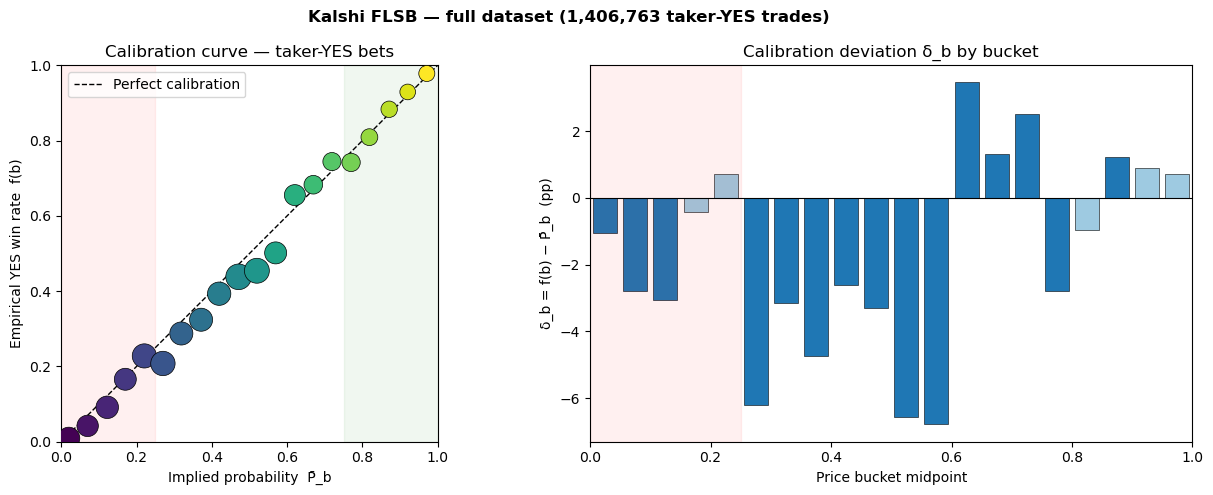

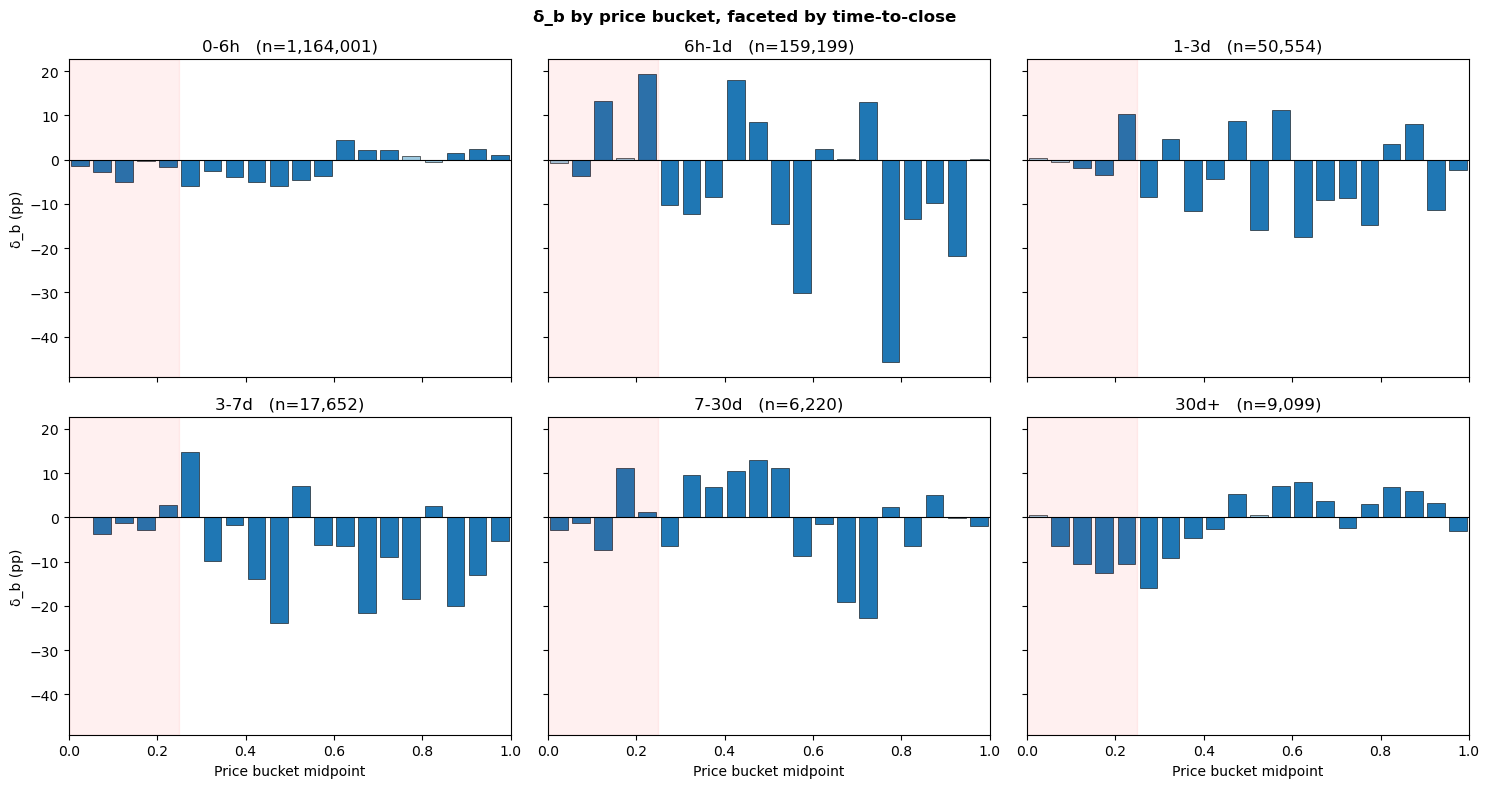

,mid,n,slope_pp_day,r2,t,pval
0,0.025,76977,0.0211,0.0001,2.2023,0.0276
1,0.075,72068,-0.0129,0.0000,-1.6948,0.0901
2,0.125,80967,-0.0755,0.0006,-6.9292,0.0000
3,0.175,76457,-0.0950,0.0007,-7.2905,0.0000
4,0.225,95826,-0.0642,0.0002,-4.1737,0.0000
5,0.275,97673,-0.0495,0.0001,-3.5741,0.0004
6,0.325,86094,-0.0739,0.0002,-4.0781,0.0000
7,0.375,85581,0.0115,0.0000,0.5760,0.5646
8,0.425,88169,0.0193,0.0000,1.2637,0.2063
9,0.475,109329,0.0266,0.0000,1.3742,0.1694


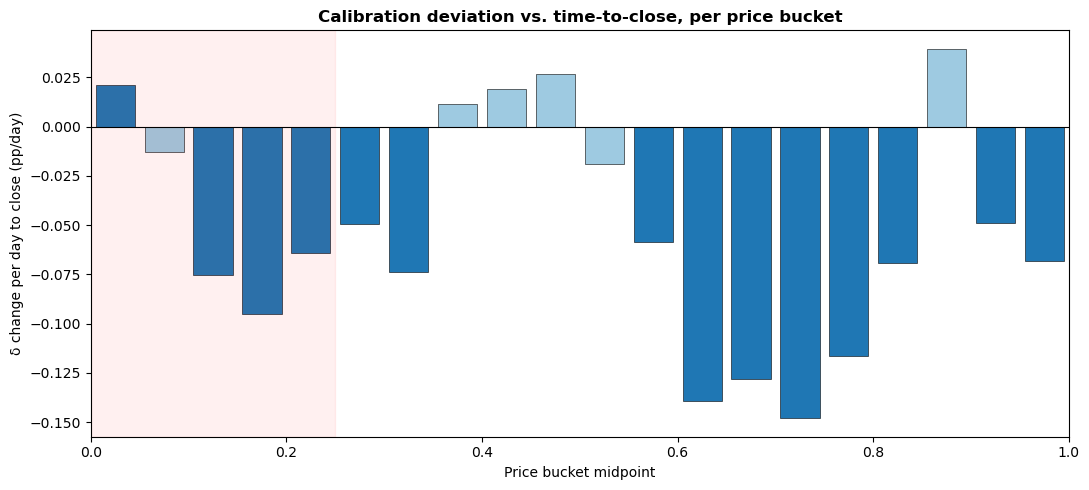

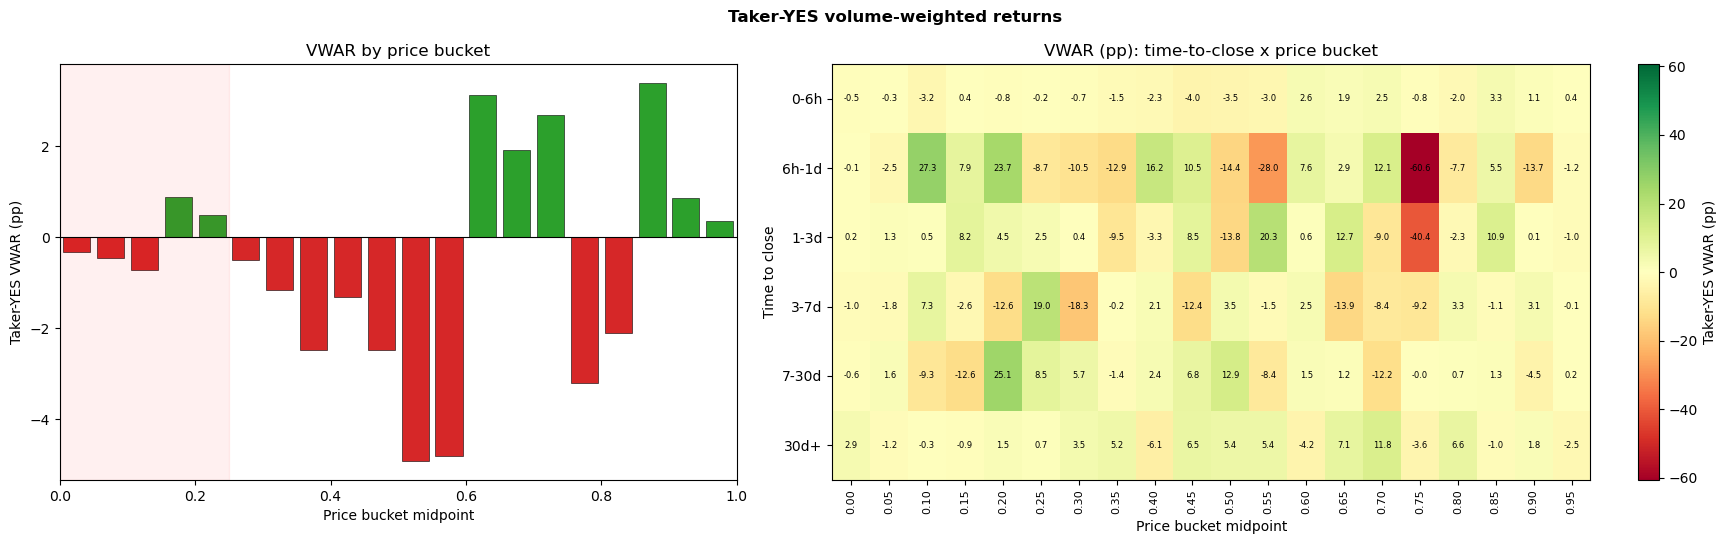

,category,taker_vwar_pp,contracts,n,maker_vwar_pp
0,Sports,-0.819,424486008.0,1648772,0.819
1,Crypto,-0.914,19438324.0,244276,0.914
2,Politics,-0.231,2066158.0,30849,0.231
3,Finance,3.192,1821010.0,20760,-3.192
4,Weather,-0.736,1817879.0,29912,0.736
5,Other,1.823,1788500.0,14484,-1.823
6,Entertainment,4.923,1098032.0,10547,-4.923
7,Science/Tech,10.947,11768.0,400,-10.947


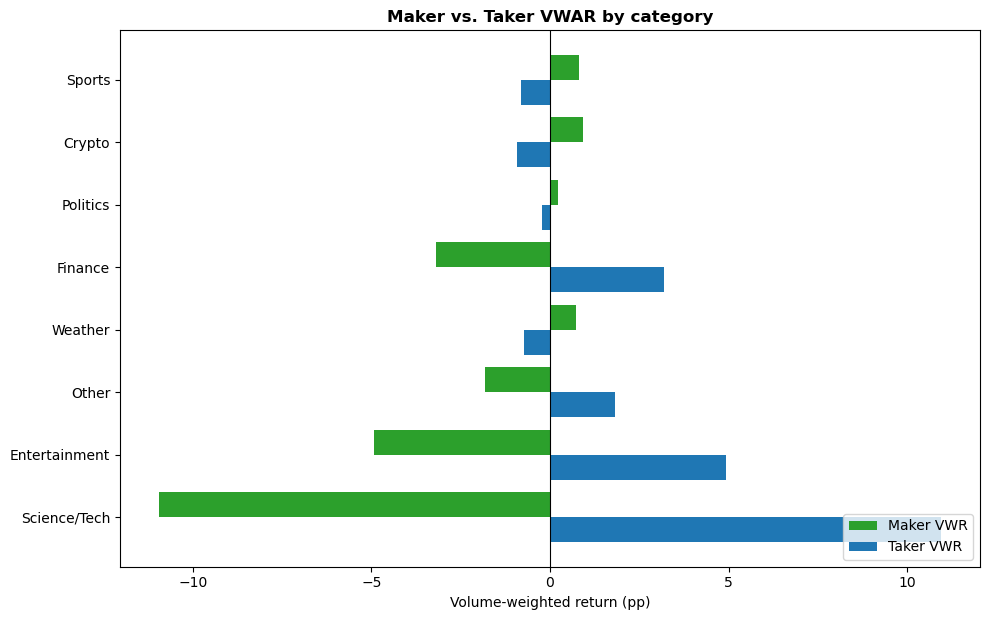

In [22]:
# ============================================================================
# Driver: process the full dataset once, then draw every plot from small tables.
# ============================================================================
# One-time cache build. BUILD_LIMIT=None -> all ~72M trades (slow first run,
# then cached locally). Use e.g. BUILD_LIMIT=2_000_000 to smoke-test end to end.
BUILD_LIMIT = 2_000_000
CACHE = build_cache(con, limit=BUILD_LIMIT)     # writes/reuses kalshi_trades.parquet
SRC = f"'{CACHE}'"

# 1. Calibration (Fig. 3). At full scale every bucket is significant, so emphasize
#    by effect size (|delta| >= 1pp) instead of p-value.
cal = calibration_table(con, SRC)
display(cal[['mid', 'n', 'pbar', 'f', 'delta', 't', 'pval']].round(4))
plot_calibration(cal, title=f'Kalshi FLSB — full dataset ({cal["n"].sum():,} taker-YES trades)',
                 sig_col=None, thresh=1.0)

# 2. delta_b faceted by time-to-close
d = calibration_by_ttc(con, SRC)
plot_delta_facets(d, sig_col=None, thresh=1.0)

# 3. delta vs time-to-close regression, per price bucket
reg = deltatime_regression(con, SRC)
display(reg[['mid', 'n', 'slope_pp_day', 'r2', 't', 'pval']].round(4))
plot_deltatime(reg)

# 4. Volume-weighted returns: by price bucket + time-to-close x price grid
pb = vwar_by_price(con, SRC)
grid = vwar_grid(con, SRC)
plot_vwar(pb, grid)

# 5. Maker vs taker VWAR by broad category (Fig. 8 style)
catt = vwar_by_category(con, SRC)
display(catt.round(3))
plot_category(catt)

In [23]:
import pandas as pd

In [24]:
pd.read_csv('figures/category_breakdown.csv')

,category,taker_vwar_pp,maker_vwar_pp,half_spread_pp,vol_share_pct,contracts,n,t,pval
0,Sports,-0.731093,0.731093,0.540319,77.041319,1.025775e+10,49744394,-214.413981,0.000000e+00
1,Other,-0.623590,0.623590,0.742527,7.505736,9.993593e+08,5268722,-77.500865,0.000000e+00
2,Finance,-0.758898,0.758898,1.148600,5.123763,6.822090e+08,2917769,-22.363413,9.135265e-111
3,Crypto,-0.557155,0.557155,1.131231,4.833860,6.436095e+08,6615296,-46.816479,0.000000e+00
4,Weather,-0.935276,0.935276,1.181106,2.760394,3.675356e+08,5838136,-72.971296,0.000000e+00
5,Politics,-2.389148,2.389148,0.692107,2.556232,3.403523e+08,1375302,-77.934468,0.000000e+00
6,Entertainment,-1.836193,1.836193,1.024905,0.171111,2.278280e+07,227250,-43.648640,0.000000e+00
7,Science/Tech,-1.137455,1.137455,1.215038,0.007585,1.009944e+06,13131,-6.881747,6.180635e-12
